### Carregando os Dados de Jogos a Partir do Arquivo `games.csv`

Agora que o arquivo `games.csv` está disponível e foi mencionado ter caracteres especiais, vamos carregá-lo em um DataFrame pandas. Vamos tentar a codificação `latin1` para lidar com possíveis caracteres não-UTF-8 e inspecionar as primeiras linhas.

In [1]:
import pandas as pd
import csv # Import the csv module to change its field size limit

file_path_csv = '/content/games.csv'

# Explicitly define the column names as provided by the user
column_names = [
    'AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
    'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
    'Supported languages', 'Full audio languages', 'Reviews', 'Header image',
    'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux',
    'Metacritic score', 'Metacritic url', 'User score', 'Positive',
    'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes',
    'Average playtime forever', 'Average playtime two weeks',
    'Median playtime forever', 'Median playtime two weeks', 'Developers',
    'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'
]

try:
    # Increase the field size limit for the csv reader to handle large text fields
    # This needs to be done before pandas.read_csv if engine='python' is used
    # The default limit is 131072, increasing it significantly
    csv.field_size_limit(2147483647) # Max possible value for a 32-bit integer

    # Load the CSV, skipping the header row (header=0) and providing explicit column names
    # Using 'on_bad_lines='skip'' to drop malformed lines instead of warning and potentially breaking the dataframe
    df_games_csv = pd.read_csv(
        file_path_csv,
        encoding='latin1',
        engine='python', # 'python' engine handles 'on_bad_lines' more robustly
        sep=',',
        header=0, # The first row is the header, which we explicitly skip to use `names`
        names=column_names, # Use the explicit column names
        on_bad_lines='skip' # Skip malformed lines
    )

    # Set 'AppID' as the index.
    # It's important to convert it to string before for consistency and to avoid mixed types.
    if 'AppID' in df_games_csv.columns:
        df_games_csv['AppID'] = df_games_csv['AppID'].astype(str)
        df_games_csv = df_games_csv.set_index('AppID')
    else:
        print("Erro: Coluna 'AppID' não encontrada após o carregamento.")

    # Exibindo as primeiras linhas do DataFrame processado
    print("DataFrame de jogos carregado do CSV (com colunas explicitamente definidas):")
    display(df_games_csv.head())

    # Exibir informações sobre o DataFrame para verificar os tipos de dados e valores ausentes
    print("\nInformações do DataFrame:")
    df_games_csv.info()

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado em {file_path_csv}")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo CSV: {e}")

Erro: Arquivo não encontrado em /content/games.csv


In [2]:
import pandas as pd
import csv

# Use o novo caminho para o arquivo no Google Drive
file_path_csv_drive = '/content/drive/MyDrive/ColabNotebooks/Dados/games.csv'

# Aumentar o limite de tamanho do campo do csv reader para lidar com campos de texto grandes
csv.field_size_limit(2147483647) # Valor máximo possível para um inteiro de 32 bits

# Explicitamente definir os nomes das colunas
column_names = [
    'AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
    'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
    'Supported languages', 'Full audio languages', 'Reviews', 'Header image',
    'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux',
    'Metacritic score', 'Metacritic url', 'User score', 'Positive',
    'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes',
    'Average playtime forever', 'Average playtime two weeks',
    'Median playtime forever', 'Median playtime two weeks', 'Developers',
    'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'
]

try:
    df_games_csv_persistent = pd.read_csv(
        file_path_csv_drive,
        encoding='latin1',
        engine='python',
        sep=',',
        header=0,
        names=column_names,
        on_bad_lines='skip'
    )

    if 'AppID' in df_games_csv_persistent.columns:
        df_games_csv_persistent['AppID'] = df_games_csv_persistent['AppID'].astype(str)
        df_games_csv_persistent = df_games_csv_persistent.set_index('AppID')
    else:
        print("Erro: Coluna 'AppID' não encontrada após o carregamento.")

    print("DataFrame de jogos carregado do Google Drive (com colunas explicitamente definidas):")
    display(df_games_csv_persistent.head())

    print("\nInformações do DataFrame carregado do Drive:")
    df_games_csv_persistent.info()

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado em {file_path_csv_drive}. Certifique-se de que o Drive está montado e o caminho está correto.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo CSV do Drive: {e}")

DataFrame de jogos carregado do Google Drive (com colunas explicitamente definidas):


,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
AppID,,,,,,,,,,,,,,,,,,,,,
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,ë²íë² íë¼ë ¸ì´ì - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,ì ì§ê²ìì¦,ì ì§ê²ìì¦,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN



Informações do DataFrame carregado do Drive:
<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        122610 non-null  object 
 1   Release date                122611 non-null  object 
 2   Estimated owners            122611 non-null  object 
 3   Peak CCU                    122611 non-null  int64  
 4   Required age                122611 non-null  int64  
 5   Price                       122611 non-null  float64
 6   Discount                    122611 non-null  int64  
 7   DLC count                   122611 non-null  int64  
 8   About the game              114162 non-null  object 
 9   Supported languages         122611 non-null  object 
 10  Full audio languages        122611 non-null  object 
 11  Reviews                     12070 non-null   object 
 12  Header image            

### Preparando os Dados para Análise: `Estimated owners` e `Price`

Agora que o `df_games_csv` foi carregado, precisamos processar a coluna `Estimated owners` para convertê-la em um formato numérico que possa ser usado para cálculos. Também iremos assegurar que a coluna `Price` está no formato correto. Vamos renomear a coluna `Estimated owners` para `Estimated_owners` para facilitar o acesso.

In [6]:
import numpy as np

# Renomear a coluna 'Estimated owners' para 'Estimated_owners' para evitar problemas com espaços
df_games_csv_persistent = df_games_csv_persistent.rename(columns={'Estimated owners': 'Estimated_owners'})

# Processar 'Estimated_owners' para extrair o valor numérico. Assumindo o formato 'X - Y'.
# Pegar o limite superior do range como o valor numérico.
# Tratar casos onde o formato pode não ser 'X - Y'.
def parse_estimated_owners(owners_str):
    if isinstance(owners_str, str):
        parts = owners_str.replace(' ', '').split('-')
        if len(parts) == 2:
            try:
                # Consideramos o limite superior do range
                return float(parts[1])
            except ValueError:
                return np.nan # Retornar NaN se a conversão falhar
    return np.nan # Retornar NaN para não-strings ou formatos inesperados

df_games_csv_persistent['Estimated_owners_numeric'] = df_games_csv_persistent['Estimated_owners'].apply(parse_estimated_owners)

# Converter a coluna 'Price' para numérico (float64) para preservar decimais,
# tratando vírgulas como separador decimal, se houver, e substituindo NaN por 0.0.
# Certifique-se de que a coluna 'Price' existe antes de tentar converter
if 'Price' in df_games_csv_persistent.columns:
    df_games_csv_persistent['Price'] = pd.to_numeric(df_games_csv_persistent['Price'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0.0).astype(float)
else:
    print("Coluna 'Price' não encontrada. Verifique o carregamento do CSV.")
    # Criar uma coluna 'Price' padrão para evitar erros downstream, se necessário
    df_games_csv_persistent['Price'] = 0.0

# Exibindo as primeiras linhas com as novas colunas e verificando os tipos de dados
print("DataFrame de jogos com 'Estimated_owners_numeric' e 'Price' processados:")
display(df_games_csv_persistent[['Name', 'Estimated_owners', 'Estimated_owners_numeric', 'Price']].head())

print("\nVerificando tipos de dados das colunas processadas:")
print(df_games_csv_persistent[['Estimated_owners_numeric', 'Price']].dtypes)

DataFrame de jogos com 'Estimated_owners_numeric' e 'Price' processados:


,Name,Estimated_owners,Estimated_owners_numeric,Price
AppID,,,,
2539430,Black Dragon Mage Playtest,0 - 0,0.0,0.00
496350,Supipara - Chapter 1 Spring Has Come!,0 - 20000,20000.0,5.24
1034400,Mystery Solitaire The Black Raven,0 - 20000,20000.0,4.99
3292190,ë²íë² íë¼ë ¸ì´ì - Vtuber Paranoia,0 - 20000,20000.0,8.99
3631080,Maze Quest VR,0 - 20000,20000.0,4.99



Verificando tipos de dados das colunas processadas:
Estimated_owners_numeric    float64
Price                       float64
dtype: object


In [7]:
import numpy as np

# Renomear a coluna 'Estimated owners' para 'Estimated_owners' para evitar problemas com espaços
df_games_csv_persistent = df_games_csv_persistent.rename(columns={'Estimated owners': 'Estimated_owners'})

# Processar 'Estimated_owners' para extrair o valor numérico. Assumindo o formato 'X - Y'.
# Pegar o limite superior do range como o valor numérico.
# Tratar casos onde o formato pode não ser 'X - Y'.
def parse_estimated_owners(owners_str):
    if isinstance(owners_str, str):
        parts = owners_str.replace(' ', '').split('-')
        if len(parts) == 2:
            try:
                # Consideramos o limite superior do range
                return float(parts[1])
            except ValueError:
                return np.nan # Retornar NaN se a conversão falhar
    return np.nan # Retornar NaN para não-strings ou formatos inesperados

df_games_csv_persistent['Estimated_owners_numeric'] = df_games_csv_persistent['Estimated_owners'].apply(parse_estimated_owners)

# Converter a coluna 'Price' para numérico (float64) para preservar decimais,
# tratando vírgulas como separador decimal, se houver, e substituindo NaN por 0.0.
# Certifique-se de que a coluna 'Price' existe antes de tentar converter
if 'Price' in df_games_csv_persistent.columns:
    df_games_csv_persistent['Price'] = pd.to_numeric(df_games_csv_persistent['Price'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0.0).astype(float)
else:
    print("Coluna 'Price' não encontrada. Verifique o carregamento do CSV.")
    # Criar uma coluna 'Price' padrão para evitar erros downstream, se necessário
    df_games_csv_persistent['Price'] = 0.0

# Exibindo as primeiras linhas com as novas colunas e verificando os tipos de dados
print("DataFrame de jogos com 'Estimated_owners_numeric' e 'Price' processados:")
display(df_games_csv_persistent[['Name', 'Estimated_owners', 'Estimated_owners_numeric', 'Price']].head())

print("\nVerificando tipos de dados das colunas processadas:")
print(df_games_csv_persistent[['Estimated_owners_numeric', 'Price']].dtypes)

DataFrame de jogos com 'Estimated_owners_numeric' e 'Price' processados:


,Name,Estimated_owners,Estimated_owners_numeric,Price
AppID,,,,
2539430,Black Dragon Mage Playtest,0 - 0,0.0,0.00
496350,Supipara - Chapter 1 Spring Has Come!,0 - 20000,20000.0,5.24
1034400,Mystery Solitaire The Black Raven,0 - 20000,20000.0,4.99
3292190,ë²íë² íë¼ë ¸ì´ì - Vtuber Paranoia,0 - 20000,20000.0,8.99
3631080,Maze Quest VR,0 - 20000,20000.0,4.99



Verificando tipos de dados das colunas processadas:
Estimated_owners_numeric    float64
Price                       float64
dtype: object


Número de jogos por faixa de preço (incrementos de $10):


,Number of Games
Price_Range_10_Inc,
Grátis,26206
$1,20104
$1-$10,64536
$11-$20,9292
$21-$30,1381
$31-$40,338
$41-$50,150
$51-$60,209
$61-$70,35


/tmp/ipykernel_3036/1801034290.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=games_by_price_range_10_inc.index, y=games_by_price_range_10_inc.values, palette='viridis')


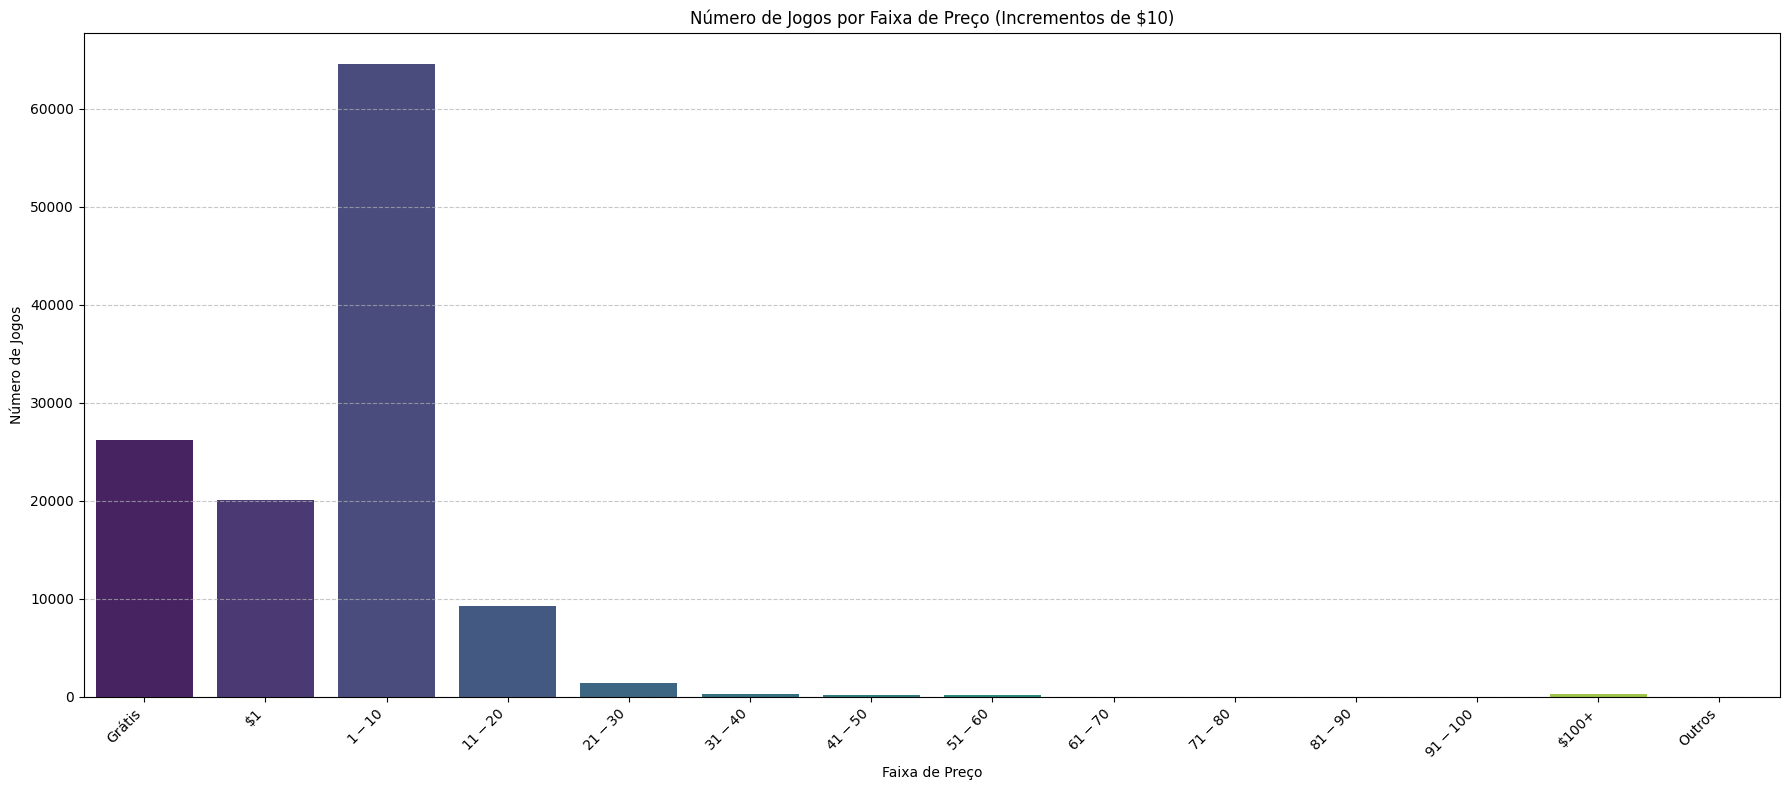

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure the 'Price' column is numeric
# This should have been handled by cell 1a27a872, but we add a safeguard.
if 'Price' not in df_games_csv_persistent.columns or not pd.api.types.is_numeric_dtype(df_games_csv_persistent['Price']):
    print("Warning: 'Price' column not found or not numeric. Attempting conversion.")
    df_games_csv_persistent['Price'] = pd.to_numeric(df_games_csv_persistent['Price'], errors='coerce').fillna(0.0)

# Define price categorization function
def categorize_price_10_inc(price):
    if price == 0:
        return 'Grátis'
    elif price > 0 and price <= 1:
        return '$1'
    elif price > 1 and price <= 10:
        return '$1-$10'
    elif price > 10 and price <= 20:
        return '$11-$20'
    elif price > 20 and price <= 30:
        return '$21-$30'
    elif price > 30 and price <= 40:
        return '$31-$40'
    elif price > 40 and price <= 50:
        return '$41-$50'
    elif price > 50 and price <= 60:
        return '$51-$60'
    elif price > 60 and price <= 70:
        return '$61-$70'
    elif price > 70 and price <= 80:
        return '$71-$80'
    elif price > 80 and price <= 90:
        return '$81-$90'
    elif price > 90 and price <= 100:
        return '$91-$100'
    elif price > 100:
        return '$100+'
    return 'Outros' # Fallback for any unhandled cases, though less likely with clean 'Price'

# Apply categorization to the 'Price' column to create 'Price_Range_10_Inc'
df_games_csv_persistent['Price_Range_10_Inc'] = df_games_csv_persistent['Price'].apply(categorize_price_10_inc)

# Define the full order of categories for consistency
price_order_full = ['Grátis', '$1', '$1-$10', '$11-$20', '$21-$30', '$31-$40', '$41-$50', '$51-$60', '$61-$70', '$71-$80', '$81-$90', '$91-$100', '$100+', 'Outros']

# Count the number of games per price range
games_by_price_range_10_inc = df_games_csv_persistent['Price_Range_10_Inc'].value_counts()

# Reindex to ensure all categories are present, filling missing ones with 0
# Only include categories that are actually present in the `games_by_price_range_10_inc` index
# and those that are part of the `price_order_full` but might not have values yet (e.g. '$100+')
# Filter price_order_full to only include relevant categories

# Get the list of unique categories actually present in the data
present_categories = games_by_price_range_10_inc.index.tolist()

# Create the final order for reindexing, including only relevant categories from full order
final_price_order = [p for p in price_order_full if p in present_categories or p == '$100+' or p == 'Outros']

games_by_price_range_10_inc = games_by_price_range_10_inc.reindex(final_price_order, fill_value=0)


print("Número de jogos por faixa de preço (incrementos de $10):")
display(games_by_price_range_10_inc.to_frame(name='Number of Games'))

# Visualizar a distribuição em um gráfico de barras
plt.figure(figsize=(18, 8))
sns.barplot(x=games_by_price_range_10_inc.index, y=games_by_price_range_10_inc.values, palette='viridis')
plt.title('Número de Jogos por Faixa de Preço (Incrementos de $10)')
plt.xlabel('Faixa de Preço')
plt.ylabel('Número de Jogos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análise: Tempo de Jogo Médio (Playtime) vs. Vendas Estimadas

Vamos agora explorar a relação entre o tempo de jogo médio (`Average playtime forever`) e as vendas estimadas (`Estimated_owners_numeric`). Para isso, vou criar uma métrica de 'Vendas Totais Estimadas' multiplicando o número de proprietários estimados pelo preço do jogo. Em seguida, visualizaremos essa relação.

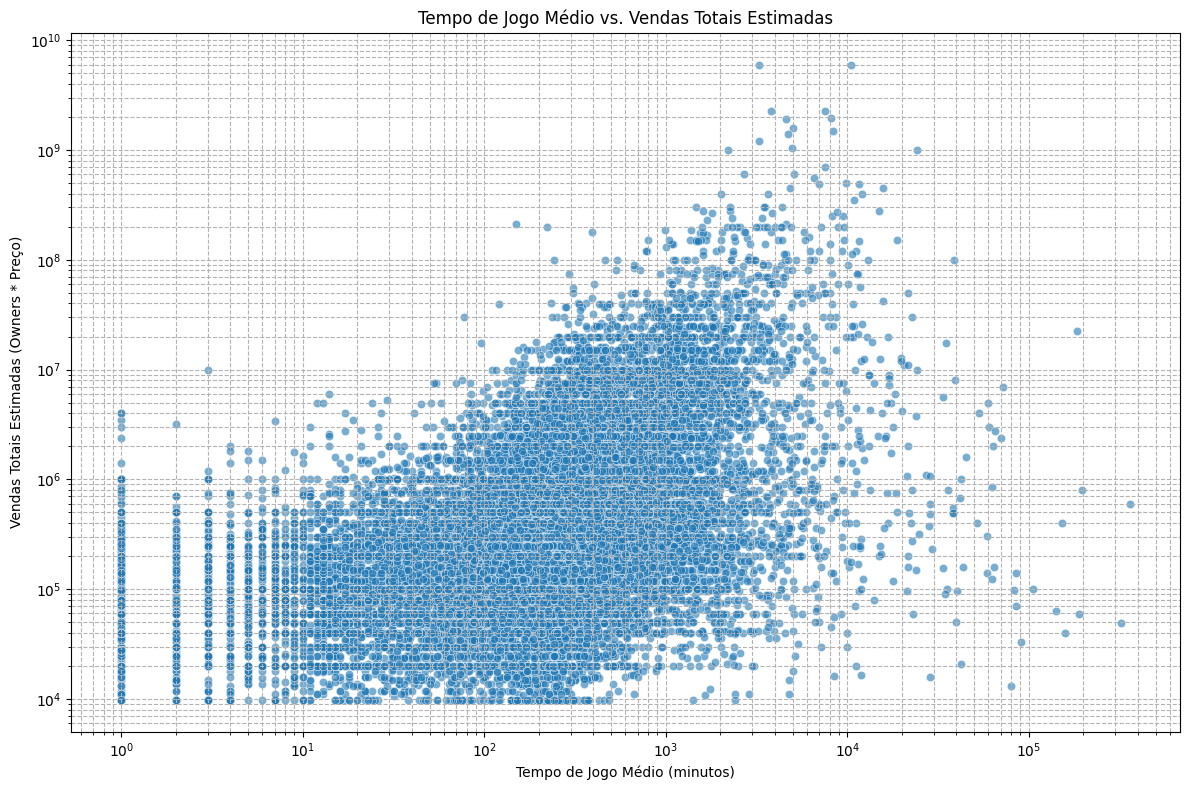


Correlação entre 'Average playtime forever' e 'Total_Estimated_Sales':
0.04147570861705488
Existe uma correlação positiva fraca entre o tempo de jogo e as vendas totais estimadas.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Certificar-se de que as colunas necessárias existem e são numéricas
# 'Estimated_owners_numeric' deve ser float, 'Price' deve ser float
# Isso é feito na célula anterior, mas verificamos novamente por segurança
if 'Estimated_owners_numeric' not in df_games_csv_persistent.columns:
    # This part should ideally not be reached if previous cells executed correctly
    print("Warning: 'Estimated_owners_numeric' not found, attempting conversion.")
    df_games_csv_persistent['Estimated_owners_numeric'] = df_games_csv_persistent['Estimated_owners'].apply(parse_estimated_owners)

if 'Price' not in df_games_csv_persistent.columns:
    # This part should ideally not be reached if previous cells executed correctly
    print("Warning: 'Price' not found, attempting conversion.")
    df_games_csv_persistent['Price'] = pd.to_numeric(df_games_csv_persistent['Price'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0.0).astype(float)


# Calcular 'Total Estimated Sales' (vendas estimadas * preço)
# Usar fillna(0) para garantir que não haja NaNs na multiplicação
df_games_csv_persistent['Total_Estimated_Sales'] = df_games_csv_persistent['Estimated_owners_numeric'].fillna(0) * df_games_csv_persistent['Price'].fillna(0)

# Filtrar jogos com pelo menos algum playtime e vendas para uma análise mais significativa
# Certificar-se de que 'Average playtime forever' é numérico
df_games_csv_persistent['Average playtime forever'] = pd.to_numeric(df_games_csv_persistent['Average playtime forever'], errors='coerce').fillna(0)

df_filtered = df_games_csv_persistent[(df_games_csv_persistent['Average playtime forever'] > 0) & (df_games_csv_persistent['Total_Estimated_Sales'] > 0)].copy()

# Verificar se df_filtered não está vazio antes de tentar plotar
if df_filtered.empty:
    print("Não há dados suficientes (jogos com playtime e vendas positivas) para gerar o gráfico.")
else:
    # Visualizar a relação entre Average playtime forever e Total Estimated Sales
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_filtered,
        x='Average playtime forever',
        y='Total_Estimated_Sales',
        alpha=0.6
    )
    plt.title('Tempo de Jogo Médio vs. Vendas Totais Estimadas')
    plt.xlabel('Tempo de Jogo Médio (minutos)')
    plt.ylabel('Vendas Totais Estimadas (Owners * Preço)')
    plt.xscale('log') # Escala logarítmica para lidar com a vasta gama de tempo de jogo
    plt.yscale('log') # Escala logarítmica para lidar com a vasta gama de vendas
    plt.grid(True, which="both", ls="--", c='0.7')
    plt.tight_layout()
    plt.show()

    print("\nCorrelação entre 'Average playtime forever' e 'Total_Estimated_Sales':")
    correlation = df_filtered[['Average playtime forever', 'Total_Estimated_Sales']].corr().iloc[0, 1]
    print(correlation)

    # Check for correlation strength
    if correlation > 0.5:
        print("Existe uma correlação positiva forte entre o tempo de jogo e as vendas totais estimadas.")
    elif correlation > 0.2:
        print("Existe uma correlação positiva moderada entre o tempo de jogo e as vendas totais estimadas.")
    elif correlation > 0:
        print("Existe uma correlação positiva fraca entre o tempo de jogo e as vendas totais estimadas.")
    else:
        print("Não existe uma correlação positiva ou a correlação é negativa.")

### Análise da Distribuição do Tempo de Jogo Médio para Definir Limites

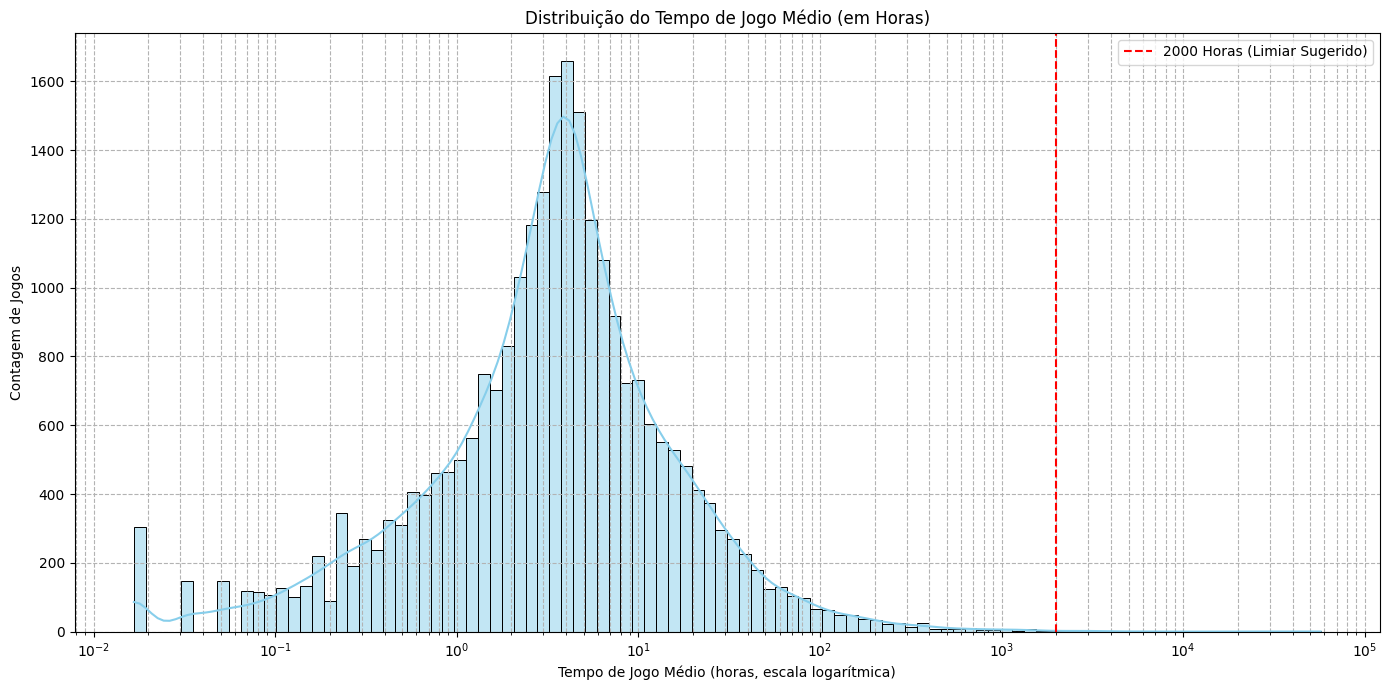

Estatísticas descritivas para o Tempo de Jogo Médio (em Horas):


,Average playtime forever (hours)
count,26119.000000
mean,16.275467
std,404.826486
min,0.016667
25%,1.433333
50%,3.616667
75%,7.650000
max,57159.066667



Quantis do Tempo de Jogo Médio (em Horas):


,Average playtime forever (hours)
0.500,3.616667
0.750,7.650000
0.900,20.066667
0.950,36.166667
0.990,151.044000
0.999,1081.187300



Número de jogos com tempo de jogo médio >= 2000 horas: 12


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Converter 'Average playtime forever' de minutos para horas
df_games_csv_persistent['Average playtime forever (hours)'] = df_games_csv_persistent['Average playtime forever'] / 60

# Filtrar jogos com tempo de jogo maior que zero para a análise de distribuição
df_playtime_positive = df_games_csv_persistent[df_games_csv_persistent['Average playtime forever (hours)'] > 0].copy()

# Plotar um histograma para visualizar a distribuição do tempo de jogo em horas
plt.figure(figsize=(14, 7))
sns.histplot(
    x=df_playtime_positive['Average playtime forever (hours)'], # Corrected: Removed redundant 'and' operator
    bins=100, # Ajustar bins para uma visualização mais granular
    kde=True, # Adicionar estimativa de densidade do kernel para suavizar a distribuição
    log_scale=True, # Usar escala logarítmica no eixo x para lidar com a grande variação
    color='skyblue'
)
plt.title('Distribuição do Tempo de Jogo Médio (em Horas)')
plt.xlabel('Tempo de Jogo Médio (horas, escala logarítmica)')
plt.ylabel('Contagem de Jogos')
plt.axvline(x=2000, color='red', linestyle='--', label='2000 Horas (Limiar Sugerido)')
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()

# Calcular estatísticas descritivas para o tempo de jogo em horas
print("Estatísticas descritivas para o Tempo de Jogo Médio (em Horas):")
display(df_playtime_positive['Average playtime forever (hours)'].describe())

# Quantis para entender a distribuição
print("\nQuantis do Tempo de Jogo Médio (em Horas):")
display(df_playtime_positive['Average playtime forever (hours)'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999]))

# Contar jogos acima de 2000 horas
jogos_acima_2000_horas = df_playtime_positive[df_playtime_positive['Average playtime forever (hours)'] >= 2000]
print(f"\nNúmero de jogos com tempo de jogo médio >= 2000 horas: {len(jogos_acima_2000_horas)}")

### Análise de Rede de Gêneros: Identificando Combinações Comuns

Vamos construir um grafo de rede para visualizar as relações entre os gêneros de jogos. Os nós do grafo representarão os gêneros, e o tamanho de cada nó será proporcional à sua frequência. As arestas entre os nós indicarão quantas vezes esses dois gêneros aparecem juntos no mesmo jogo.

Nós: 30 | Arestas: 435


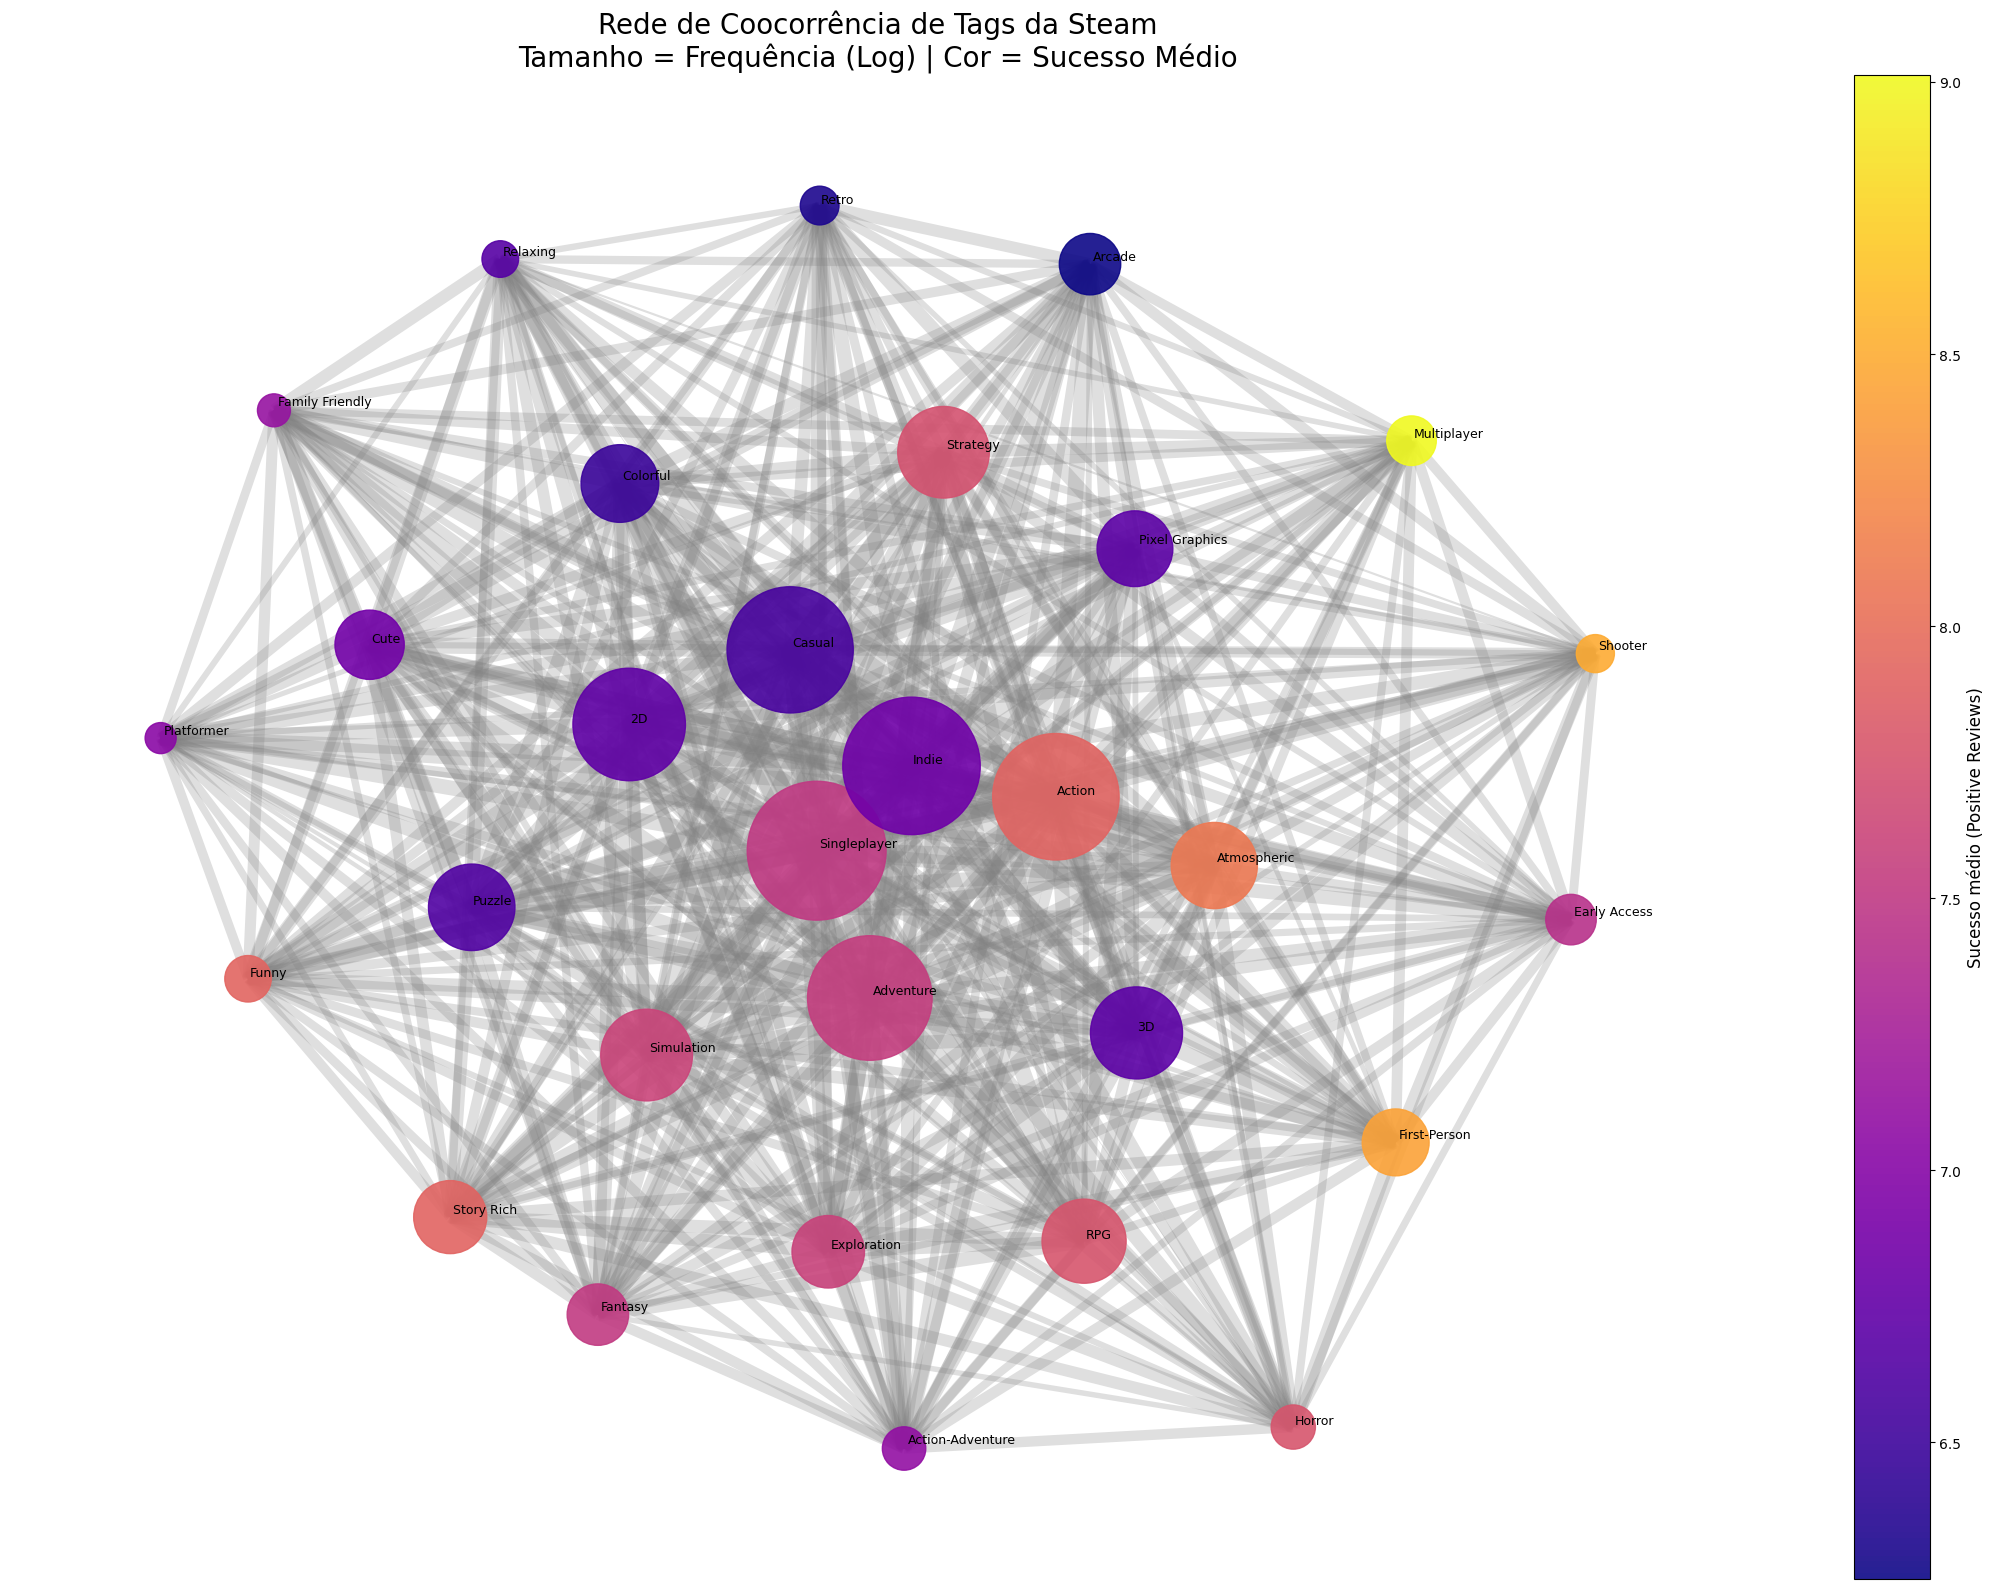

In [17]:
!pip install adjustText
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from collections import Counter
from adjustText import adjust_text

# =====================================================
# CONFIGURAÇÕES
# =====================================================

TOP_N_TAGS = 30

MIN_EDGE_WEIGHT = 100

# New configurable parameters for visual scaling
MIN_NODE_VISUAL_SIZE = 500
MAX_NODE_VISUAL_SIZE = 10000

MIN_EDGE_WIDTH_VISUAL = 0.5
MAX_EDGE_WIDTH_VISUAL = 15.5

# =====================================================
# PREPARAÇÃO
# =====================================================

df = df_games_csv_persistent.copy()

df['Positive'] = pd.to_numeric(
    df['Positive'],
    errors='coerce'
)

df = df.dropna(subset=['Positive'])

# =====================================================
# EXTRAÇÃO DAS TAGS
# =====================================================

def parse_tags(x):

    if pd.isna(x):
        return []

    return [
        tag.strip()
        for tag in str(x).split(',')
        if len(tag.strip()) > 0
    ]

df['Tags_list'] = df['Tags'].apply(parse_tags)

# =====================================================
# FREQUÊNCIA DAS TAGS
# =====================================================

tag_counter = Counter()

for tags in df['Tags_list']:
    tag_counter.update(tags)

top_tags = dict(
    tag_counter.most_common(TOP_N_TAGS)
)

# =====================================================
# SUCESSO MÉDIO POR TAG
# =====================================================

tag_success = {}

for tag in top_tags:

    mask = df['Tags_list'].apply(
        lambda tags: tag in tags
    )

    tag_success[tag] = (
        df.loc[mask, 'Positive']
        .mean()
    )

# =====================================================
# COOCORRÊNCIAS
# =====================================================

pair_counter = Counter()

for tags in df['Tags_list']:

    tags = [
        t for t in tags
        if t in top_tags
    ]

    tags = list(set(tags))

    for pair in combinations(
        sorted(tags),
        2
    ):
        pair_counter[pair] += 1

# =====================================================
# GRAFO
# =====================================================

G = nx.Graph()

for tag, count in top_tags.items():

    G.add_node(
        tag,
        count=count,
        success=tag_success[tag]
    )

for (t1, t2), weight in pair_counter.items():

    if weight >= MIN_EDGE_WEIGHT:

        G.add_edge(
            t1,
            t2,
            weight=weight
        )

print(
    f"Nós: {G.number_of_nodes()} | "
    f"Arestas: {G.number_of_edges()}"
)

# =====================================================
# LAYOUT
# =====================================================

pos = nx.spring_layout(
    G,
    k=2.5,
    iterations=500,
    seed=42
)

# =====================================================
# TAMANHO DOS NÓS (LOGARITMICO)
# =====================================================

counts = np.array([
    G.nodes[n]['count']
    for n in G.nodes()
])

# Apply logarithmic scaling for node sizes
if len(counts) > 0:
    # Use log1p to handle zero counts and compress larger values
    log_counts = np.log1p(counts)
    min_log_count = log_counts.min()
    max_log_count = log_counts.max()
    # Avoid division by zero if all log counts are the same
    if (max_log_count - min_log_count) == 0:
        node_sizes = np.full_like(log_counts, MIN_NODE_VISUAL_SIZE)
    else:
        normalized_log_counts = (log_counts - min_log_count) / (max_log_count - min_log_count)
        node_sizes = (normalized_log_counts * (MAX_NODE_VISUAL_SIZE - MIN_NODE_VISUAL_SIZE)) + MIN_NODE_VISUAL_SIZE
else:
    node_sizes = []

# =====================================================
# COR DOS NÓS
# =====================================================

node_colors = np.array([
    np.log1p(
        G.nodes[n]['success']
    )
    for n in G.nodes()
])

# =====================================================
# ESPESSURA DAS ARESTAS (LOGARITMICA)
# =====================================================

weights = np.array([
    G[u][v]['weight']
    for u, v in G.edges()
])

# Apply logarithmic scaling for edge widths
if len(weights) > 0:
    # Use log1p to handle zero weights and compress larger values
    log_weights = np.log1p(weights)
    min_log_weight = log_weights.min()
    max_log_weight = log_weights.max()
    # Avoid division by zero if all log weights are the same
    if (max_log_weight - min_log_weight) == 0:
        edge_widths = np.full_like(log_weights, MIN_EDGE_WIDTH_VISUAL)
    else:
        normalized_log_weights = (log_weights - min_log_weight) / (max_log_weight - min_log_weight + 1e-9)
        edge_widths = (normalized_log_weights * (MAX_EDGE_WIDTH_VISUAL - MIN_EDGE_WIDTH_VISUAL)) + MIN_EDGE_WIDTH_VISUAL
else:
    edge_widths = []

# =====================================================
# DESENHO
# =====================================================

plt.figure(
    figsize=(22, 16)
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color='gray',
    alpha=0.25
)

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap='plasma',
    alpha=0.9
)

# =====================================================
# LABELS AJUSTADOS
# =====================================================

texts = []

for node, (x, y) in pos.items():

    texts.append(
        plt.text(
            x,
            y,
            node,
            fontsize=9
        )
    )

adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        alpha=0.3
    )
)

# =====================================================
# COLORBAR
# =====================================================

cbar = plt.colorbar(nodes)

cbar.set_label(
    'Sucesso médio (Positive Reviews)',
    fontsize=12
)

# =====================================================
# LEGENDA
# =====================================================

plt.title(
    'Rede de Coocorrência de Tags da Steam\n'
    'Tamanho = Frequência (Log) | Cor = Sucesso Médio',
    fontsize=20
)

plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the owner_midpoint function as provided in the prompt
def owner_midpoint(owner_range):

    try:
        low, high = owner_range.split('-')

        low = int(low.replace(',', '').strip())
        high = int(high.replace(',', '').strip())

        return (low + high) / 2

    except:
        return np.nan

# Create a copy of the main DataFrame to work with
df = df_games_csv_persistent.copy()

# Convert 'Estimated_owners' (already renamed) to numeric 'Owners_num' using the provided function
df['Owners_num'] = (
    df['Estimated_owners']
    .astype(str)
    .apply(owner_midpoint)
)

# Convert 'Positive', 'Negative', and 'Average playtime forever' to numeric
df['Positive'] = pd.to_numeric(
    df['Positive'],
    errors='coerce'
)

df['Negative'] = pd.to_numeric(
    df['Negative'],
    errors='coerce'
)

df['Average playtime forever'] = pd.to_numeric(
    df['Average playtime forever'],
    errors='coerce'
)

print("Data preparation complete. Displaying head of relevant columns:")
display(df[['Estimated_owners', 'Owners_num', 'Positive', 'Negative', 'Average playtime forever']].head())

Data preparation complete. Displaying head of relevant columns:


,Estimated_owners,Owners_num,Positive,Negative,Average playtime forever
AppID,,,,,
2539430,0 - 0,0.0,0,0,0
496350,0 - 20000,10000.0,252,3,8
1034400,0 - 20000,10000.0,21,3,0
3292190,0 - 20000,10000.0,0,0,0
3631080,0 - 20000,10000.0,0,0,0


In [ ]:
# Explode the 'Tags' column into individual rows
df['Tags_list'] = (
    df['Tags']
    .fillna('')
    .apply(lambda x: [t.strip() for t in str(x).split(',') if t.strip()]) # Ensure empty strings are not added as tags
)

df_tags = (
    df
    .explode('Tags_list')
)

# Filter out rows where 'Tags_list' is an empty string that might have passed through
df_tags = df_tags[df_tags['Tags_list'] != '']

# Aggregate statistics by Tag
tag_stats = (
    df_tags
    .groupby('Tags_list')
    .agg(
        game_count=('Name', 'count'),
        avg_owners=('Owners_num', 'mean'),
        avg_playtime=('Average playtime forever', 'mean'),
        positives=('Positive', 'sum'),
        negatives=('Negative', 'sum')
    )
)

print("Tags exploded and aggregated. Displaying head of tag_stats:")
display(tag_stats.head())

In [ ]:
# Calculate the approval ratio
tag_stats['approval_ratio'] = (
    tag_stats['positives']
    /
    (
        tag_stats['positives']
        +
        tag_stats['negatives']
        + 1 # Add 1 to avoid division by zero
    )
)

# Filter to include only tags with at least 100 games
tag_stats = tag_stats[
    tag_stats['game_count'] >= 100
]

print("Approval ratio calculated and tags filtered. Displaying head of processed tag_stats:")
display(tag_stats.head())

### Análise: Heatmap Temporal das Tags - Evolução por Contagem de Jogos

Vamos agora criar um heatmap temporal para visualizar como a popularidade das tags (gêneros) mudou ao longo dos anos. Em vez de usar a média de 'owners' (proprietários), vamos usar a **contagem de jogos** para mostrar diretamente o surgimento, crescimento e declínio de cada tag. Isso nos permitirá identificar tendências de forma mais clara.

In [14]:
# Crie uma cópia do DataFrame para garantir que as modificações não afetem análises anteriores
df_temp_heatmap_genres = df_games_csv_persistent.copy()

# 1. Converter 'Release date' para datetime e extrair o ano
df_temp_heatmap_genres['Release date'] = pd.to_datetime(
    df_temp_heatmap_genres['Release date'],
    errors='coerce' # Converte datas inválidas para NaT (Not a Time)
)

df_temp_heatmap_genres['Year'] = (
    df_temp_heatmap_genres['Release date']
    .dt.year
)

# Filtrar anos válidos para a análise
df_temp_heatmap_genres = df_temp_heatmap_genres.dropna(subset=['Year']).copy()
df_temp_heatmap_genres['Year'] = df_temp_heatmap_genres['Year'].astype(int)

# 2. Preparar a coluna 'Genres_list'
def parse_genres(x):
    if pd.isna(x):
        return []
    return [genre.strip() for genre in str(x).split(',') if genre.strip()]

df_temp_heatmap_genres['Genres_list'] = df_temp_heatmap_genres['Genres'].apply(parse_genres)

# Explode a coluna de gêneros para ter um gênero por linha
df_exploded_genres = df_temp_heatmap_genres.explode('Genres_list')

# Filtra gêneros vazios que podem ter surgido de registros sem gêneros
df_exploded_genres = df_exploded_genres[df_exploded_genres['Genres_list'] != ''].copy()

# Define o número de gêneros a serem analisados
TOP_N_GENRES = 20 # Using 20 as a reasonable number for top genres

# 3. Selecionar os top N gêneros com base na frequência total
top_genres_list = (
    df_exploded_genres['Genres_list']
    .value_counts()
    .head(TOP_N_GENRES)
    .index.tolist()
)

# 4. Filtrar o DataFrame para incluir apenas os top gêneros e anos válidos
df_heat_genres = df_exploded_genres[
    df_exploded_genres['Genres_list'].isin(top_genres_list)
].copy()

# 5. Agrupar por Genres_list e Ano, e contar o número de jogos
heatmap_data_count_genres = (
    df_heat_genres
    .groupby(['Genres_list', 'Year'])
    .size() # Usar .size() para contar o número de jogos
    .rename('Game_Count') # Renomear a série resultante para 'Game_Count'
    .reset_index()
)

# 6. Pivotar a tabela
pivot_count_genres = (
    heatmap_data_count_genres
    .pivot(
        index='Genres_list',
        columns='Year',
        values='Game_Count'
    )
)

print("DataFrame pivotado para o heatmap temporal (contagem de jogos por gênero):")
display(pivot_count_genres.head())

DataFrame pivotado para o heatmap temporal (contagem de jogos por gênero):


Year,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Genres_list,,,,,,,,,,,,,,,,,,,,,
Action,2.0,1.0,2.0,2.0,3.0,1.0,2.0,6.0,2.0,19.0,...,2616.0,3161.0,3010.0,3701.0,4173.0,4577.0,5514.0,7011.0,8027.0,30.0
Adventure,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,2267.0,2797.0,2893.0,3495.0,4286.0,4664.0,5499.0,7241.0,8372.0,28.0
Animation & Modeling,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,46.0,42.0,38.0,44.0,37.0,45.0,54.0,50.0,64.0,NaN
Casual,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,20.0,...,2376.0,3351.0,3073.0,3887.0,4794.0,5098.0,5997.0,8344.0,10120.0,50.0
Design & Illustration,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,67.0,46.0,47.0,55.0,47.0,43.0,69.0,60.0,65.0,NaN


In [18]:
pip install joypy

### Análise: Ridge Plot da Evolução Temporal das Tags

Vamos agora visualizar a evolução das tags usando um Ridge Plot. Este tipo de gráfico é excelente para mostrar a distribuição e a densidade de uma variável (neste caso, anos) por diferentes categorias (as tags), permitindo identificar visualmente quando cada tag ganhou ou perdeu popularidade ao longo do tempo.

In [19]:
!pip install adjustText

### Análise: Heatmap de Crescimento Anual das Tags

Em vez de mostrar a contagem absoluta de jogos por tag e ano, este heatmap visualiza o **crescimento percentual** da contagem de jogos em relação ao ano anterior para cada tag. Isso nos permite identificar rapidamente períodos de aceleração ou desaceleração na popularidade de cada tag.

*   **Cores Quentes (Vermelho)**: Indicam uma **queda** no número de jogos em relação ao ano anterior.
*   **Cores Frias (Azul)**: Indicam um **crescimento** no número de jogos em relação ao ano anterior.
*   **Branco/Neutro**: Indicam **estabilidade** (crescimento zero ou muito próximo de zero).

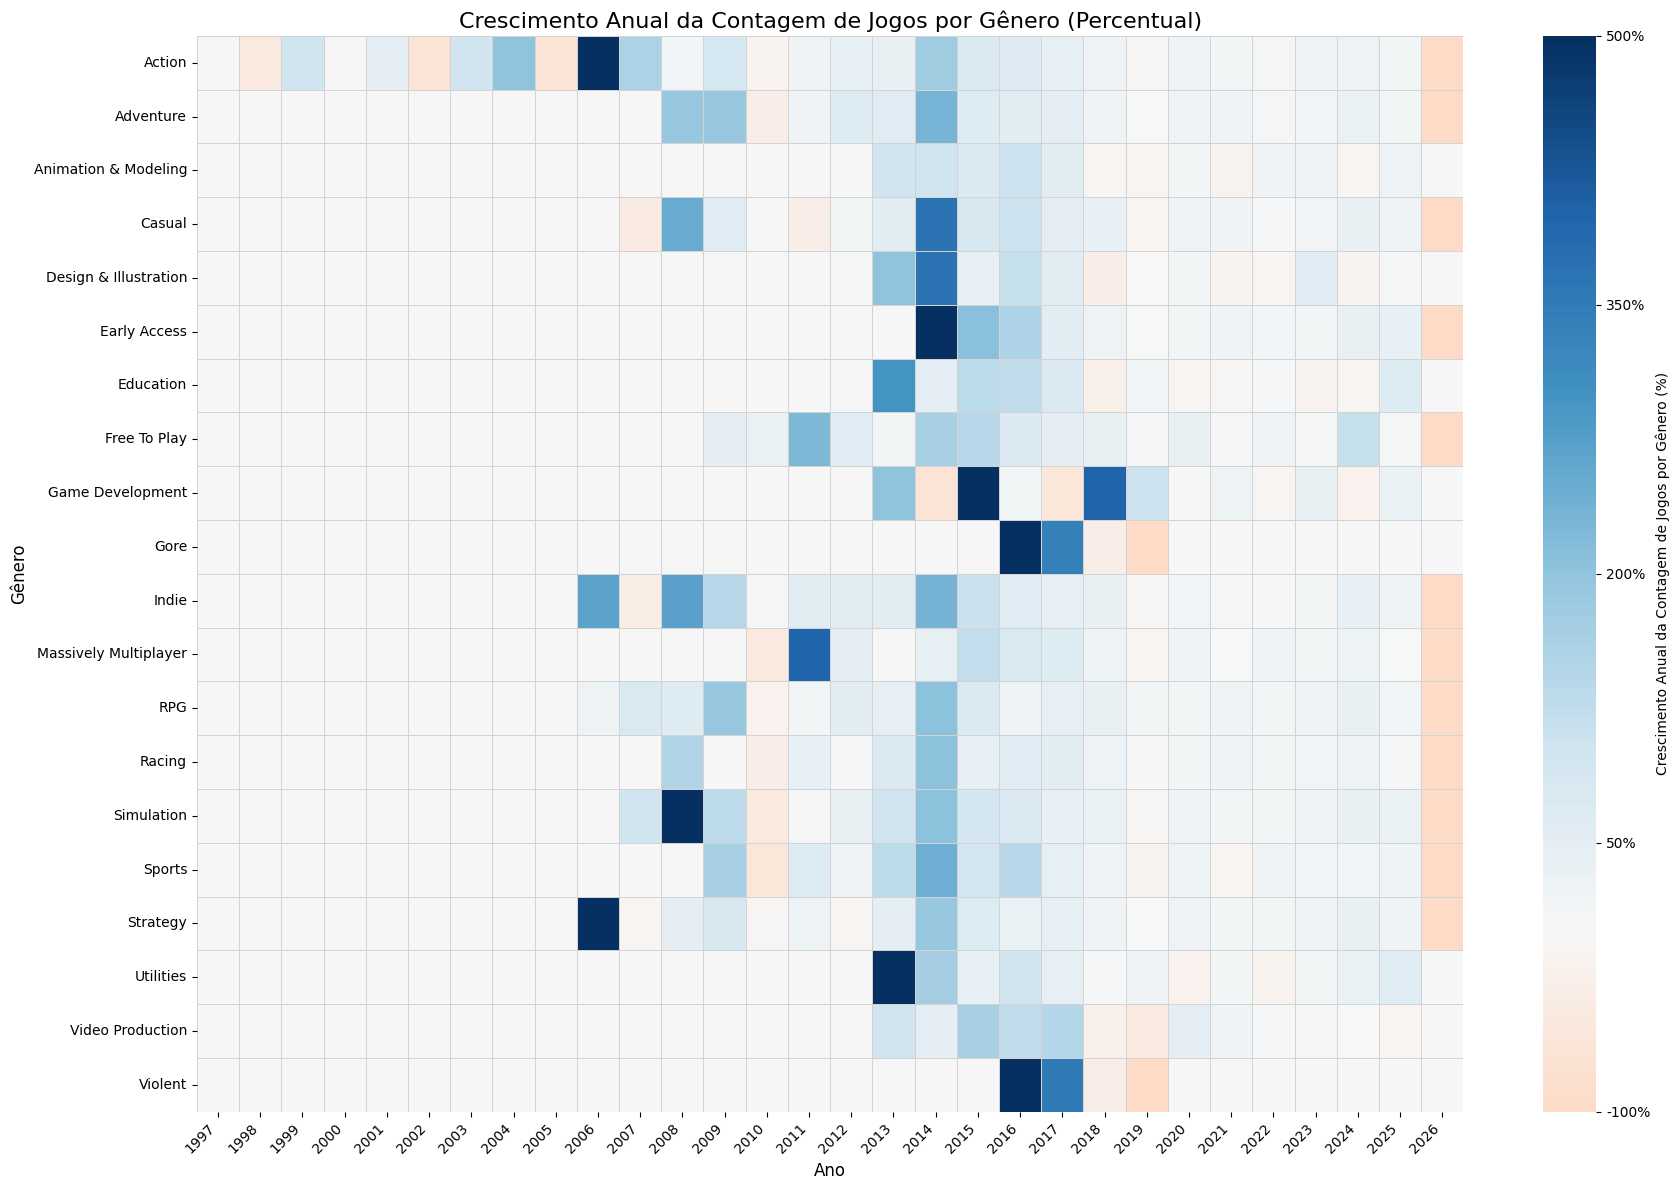

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate year-over-year percentage change for Game_Count by genre
# The .pct_change(axis=1) method calculates the percentage change along columns (years)
# It returns (current - previous) / previous. Multiplying by 100 for percentage.
growth_df_genres = pivot_count_genres.pct_change(axis=1, fill_method=None) * 100

# Handle infinite values that arise from a previous year having 0 games
# and the current year having >0 games (e.g., from 0 to 1 game is infinite growth).
# Cap these at a high positive value for better visualization.
max_growth_cap = 500  # Cap at 500% growth
growth_df_genres = growth_df_genres.replace([np.inf, -np.inf], max_growth_cap)

# Fill NaN values with 0. NaN usually indicates no prior data (first year of a genre)
# or no games in both current and previous year. For visualization, 0 represents no change.
growth_df_genres = growth_df_genres.fillna(0)

# Cap the minimum growth at -100% (a complete decline from a positive base)
# This is already handled by pct_change if current year count is 0 and previous was >0.
min_growth_cap = -100
growth_df_genres = growth_df_genres.clip(lower=min_growth_cap, upper=max_growth_cap)

# Generate the heatmap for genres
plt.figure(figsize=(18, 12))
sns.heatmap(
    growth_df_genres,
    cmap='RdBu',  # Diverging colormap: Red for decline, Blue for growth
    center=0,     # Center the colormap at 0 (white) for stability
    linewidths=.5,
    linecolor='lightgray',
    vmin=min_growth_cap, # Set minimum value for colorbar
    vmax=max_growth_cap, # Set maximum value for colorbar
    cbar_kws={
        'label': 'Crescimento Anual da Contagem de Jogos por Gênero (%)',
        'format': '%.0f%%', # Format labels as percentage
        'ticks': np.linspace(min_growth_cap, max_growth_cap, 5, dtype=int) # Explicitly set 5 ticks including min and max
    }
)

plt.title(
    'Crescimento Anual da Contagem de Jogos por Gênero (Percentual)',
    fontsize=16
)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Gênero', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Análise: Heatmap Temporal das Tags - Contagem Absoluta de Jogos

Este heatmap visualiza a **contagem absoluta de jogos lançados** para cada tag em cada ano. Ele nos permite ver a popularidade direta de uma tag em um determinado período, sem focar no crescimento percentual.

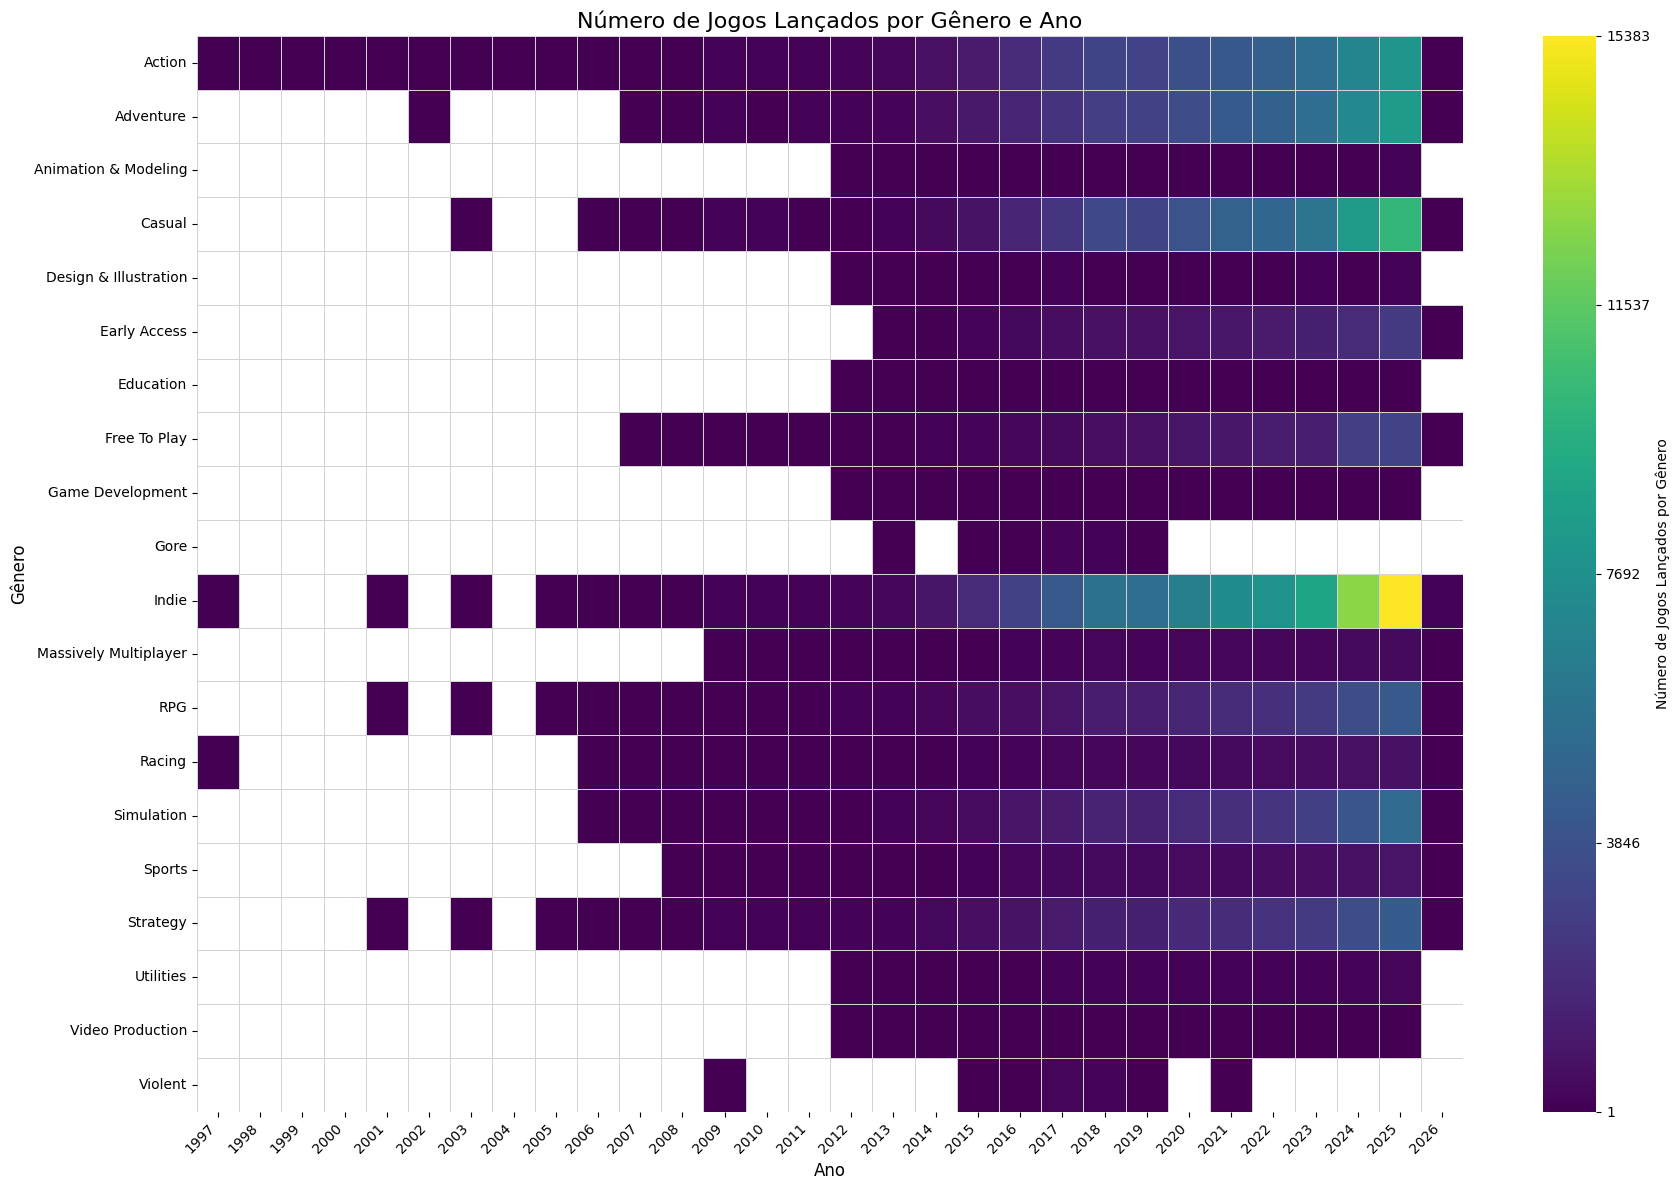

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate min and max values for the color bar
# Ensure min is at least 0, even if the actual min is higher, for clarity with 'Game_Count'
min_game_count = np.nanmin(pivot_count_genres.values) if not pivot_count_genres.empty else 0
min_game_count = max(0, min_game_count)
max_game_count = np.nanmax(pivot_count_genres.values) if not pivot_count_genres.empty else 1 # Ensure vmax is at least 1

# Gerar o heatmap usando a contagem de jogos por gênero (pivot_count_genres)
plt.figure(figsize=(18,12))

sns.heatmap(
    pivot_count_genres, # Usar a contagem de jogos por gênero diretamente
    cmap='viridis', # Escolha uma colormap adequada para contagens (sequencial)
    linewidths=.5,
    linecolor='lightgray',
    vmin=min_game_count, # Definir o valor mínimo da colorbar
    vmax=max_game_count, # Definir o valor máximo da colorbar
    cbar_kws={
        'label': 'Número de Jogos Lançados por Gênero',
        'format': '%.0f', # Formatar os rótulos da colorbar como inteiros
        'ticks': np.linspace(min_game_count, max_game_count, 5, dtype=int) # Explicitly set 5 ticks including min and max
    }
)

plt.title(
    'Número de Jogos Lançados por Gênero e Ano',
    fontsize=16
)

plt.xlabel('Ano', fontsize=12)
plt.ylabel('Gênero', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Análise: Paradoxo do Preço - O Dinheiro Compra Mais Diversão?

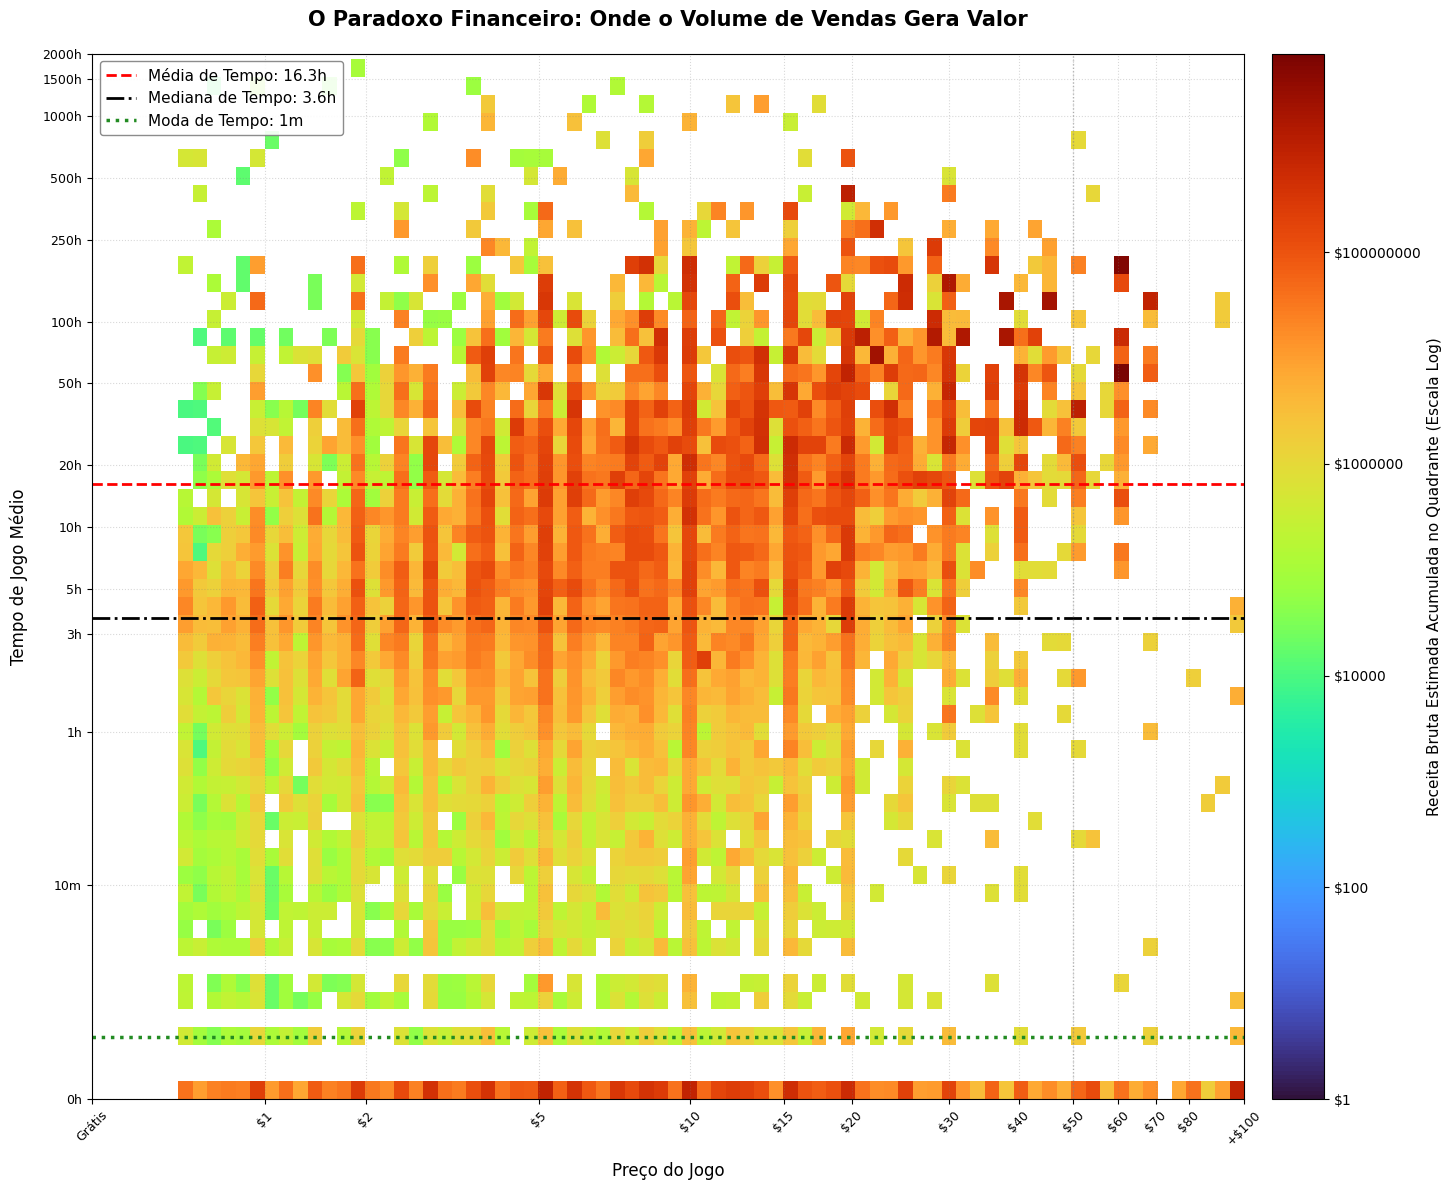

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LogNorm
from scipy import stats
import pandas as pd # Make sure pandas is imported

# --- Robustness Check and Preprocessing for 'Estimated_owners_numeric' and 'Price' ---
# This block ensures critical columns are correctly formatted,
# in case preceding cells were skipped or the kernel was reset.

# Ensure 'Estimated_owners_numeric' exists and is numeric
if 'Estimated_owners_numeric' not in df_games_csv_persistent.columns:
    print("Pre-processing: 'Estimated_owners_numeric' column not found. Attempting to create it.")

    # Check for original 'Estimated owners' column
    if 'Estimated owners' in df_games_csv_persistent.columns:
        df_games_csv_persistent = df_games_csv_persistent.rename(columns={'Estimated owners': 'Estimated_owners'})

    # If 'Estimated_owners' is still not present, or if 'Estimated owners' was the initial column
    # Ensure a consistent 'Estimated_owners' column for parsing
    if 'Estimated_owners' not in df_games_csv_persistent.columns and 'Estimated owners' in df_games_csv_persistent.columns:
        df_games_csv_persistent['Estimated_owners'] = df_games_csv_persistent['Estimated owners']
    elif 'Estimated_owners' not in df_games_csv_persistent.columns: # Fallback if neither original nor renamed column is found
        print("Warning: Neither 'Estimated owners' nor 'Estimated_owners' found. Cannot create 'Estimated_owners_numeric'. Setting to NaN.")
        df_games_csv_persistent['Estimated_owners_numeric'] = np.nan

    if 'Estimated_owners' in df_games_csv_persistent.columns:
        # Define parsing function to extract numeric value from 'X - Y' string format
        def parse_estimated_owners(owners_str):
            if isinstance(owners_str, str):
                parts = owners_str.replace(' ', '').split('-')
                if len(parts) == 2:
                    try:
                        return float(parts[1])
                    except ValueError:
                        return np.nan # Return NaN if conversion fails
            return np.nan # Return NaN for non-strings or unexpected formats

        df_games_csv_persistent['Estimated_owners_numeric'] = df_games_csv_persistent['Estimated_owners'].apply(parse_estimated_owners)
    else:
        # Fallback if somehow 'Estimated_owners' could not be established
        df_games_csv_persistent['Estimated_owners_numeric'] = np.nan


# Ensure 'Price' column is numeric (float64)
if 'Price' not in df_games_csv_persistent.columns or not pd.api.types.is_numeric_dtype(df_games_csv_persistent['Price']):
    print("Pre-processing: 'Price' column not found or not numeric. Attempting conversion.")
    if 'Price' in df_games_csv_persistent.columns:
        df_games_csv_persistent['Price'] = pd.to_numeric(df_games_csv_persistent['Price'].astype(str).replace(',', '.'), errors='coerce').fillna(0.0).astype(float)
    else:
        df_games_csv_persistent['Price'] = 0.0 # Default if column is entirely missing

# --- End of Robustness Check ---


# 1. Filtrar dados válidos (Garantindo que Estimated_owners_numeric existam e sejam >= 0)
# Ajuste o nome da coluna 'Owners' se no seu CSV se chamar 'Sales' ou 'Vendas'
df_price_playtime = df_games_csv_persistent[
    (df_games_csv_persistent['Price'] >= 0) &
    (df_games_csv_persistent['Average playtime forever'] >= 0) &
    (df_games_csv_persistent['Estimated_owners_numeric'] >= 0) # Use a coluna numérica processada
].copy()

# --- 💵 CÁLCULO DA RECEITA ESTIMADA POR JOGO ---
df_price_playtime['Revenue'] = df_price_playtime['Price'] * df_price_playtime['Estimated_owners_numeric'] # Use a coluna numérica processada

# --- CÁLCULO DAS MÉTRICAS ESTATÍSTICAS REAL (Em Minutos) ---
df_jogados = df_price_playtime[df_price_playtime['Average playtime forever'] > 0]

minutos_media = df_jogados['Average playtime forever'].mean()
minutos_mediana = df_jogados['Average playtime forever'].median()
minutos_moda = stats.mode(df_jogados['Average playtime forever'], keepdims=True).mode[0]

log_media = np.log10(minutos_media + 1)
log_mediana = np.log10(minutos_mediana + 1)
log_moda = np.log10(minutos_moda + 1)

# --- TRATAMENTO DOS PREÇOS ---
df_price_playtime['Price_Capped'] = np.where(df_price_playtime['Price'] > 100, 100, df_price_playtime['Price'])
df_price_playtime['Log_Price'] = np.log10(df_price_playtime['Price_Capped'] + 1)
df_price_playtime['Log_Playtime'] = np.log10(df_price_playtime['Average playtime forever'] + 1)

# 2. Preparar os dados do histograma 2D ponderado por RECEITA
x_data = df_price_playtime['Log_Price'].values
y_data = df_price_playtime['Log_Playtime'].values
weights_data = df_price_playtime['Revenue'].values  # <--- INJEÇÃO DE VENDAS (RECEITA)

x_min, x_max = x_data.min(), x_data.max()
y_min, y_max = y_data.min(), y_data.max()

bins_x = np.linspace(x_min, x_max, 80 + 1)
bins_y = np.linspace(y_min, y_max, 75 + 1)

# Compute the 2D histogram acumulando a RECEITA (usando o parâmetro weights)
H_revenue, xedges, yedges = np.histogram2d(x_data, y_data, bins=[bins_x, bins_y], weights=weights_data)

# TRATAMENTO VISUAL CRUCIAL: pcolormesh renderiza o valor 0 como a cor mais escura do cmap.
# Substituir 0 por NaN faz com que os quadrantes vazios fiquem totalmente brancos e limpos.
H_revenue[H_revenue == 0] = np.nan

# Definir limites da barra de cores logarítmica da receita (mínimo de $1 até o bloco mais lucrativo)
max_revenue = np.nanmax(H_revenue) if np.nanmax(H_revenue) > 1 else 1000
log_colorbar_norm = LogNorm(vmin=1, vmax=max_revenue)

# 3. Configurar figura de alta resolução
fig, ax = plt.subplots(figsize=(15, 12), dpi=100)

# 4. Plotar o mapa térmico usando pcolormesh (Matriz transposta H_revenue.T)
mesh = ax.pcolormesh(xedges, yedges, H_revenue.T, cmap='turbo', norm=log_colorbar_norm, shading='auto')

# Adicionar colorbar manualmente ajustada para moeda
cbar = fig.colorbar(mesh, ax=ax, pad=0.02, format='$%.0f')
cbar.set_label('Receita Bruta Estimada Acumulada no Quadrante (Escala Log)', fontsize=11)

# --- LIMITE VERTICAL EXPANDIDO (Até 2.000 Horas) ---
ax.set_ylim(0, np.log10(120000 + 1))

# 5. Ajustar as marcações dos eixos
x_ticks = [0, 1, 2, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 100]
ax.set_xticks(np.log10(np.array(x_ticks) + 1))
x_labels = ['Grátis'] + [f"${x}" for x in x_ticks[1:-1]] + ['+$100']
ax.set_xticklabels(x_labels, rotation=45, fontsize=9)

y_ticks = [0, 10, 60, 180, 300, 600, 1200, 3000, 6000, 15000, 30000, 60000, 90000, 120000]
ax.set_yticks(np.log10(np.array(y_ticks) + 1))
ax.set_yticklabels(['0h', '10m', '1h', '3h', '5h', '10h', '20h', '50h', '100h', '250h', '500h', '1000h', '1500h', '2000h'], fontsize=9)

ax.grid(True, which='both', linestyle=':', alpha=0.3, color='gray')

# --- 🎯 LINHAS DAS MÉTRICAS ESTATÍSTICAS ---
def formatar_horas(minutos):
    horas = minutos / 60
    return f"{horas:.1f}h" if horas >= 1 else f"{int(minutos)}m"

# Linha da Média (Vermelha)
ax.axhline(y=log_media, color='red', linestyle='--', linewidth=2,
           label=f'Média de Tempo: {formatar_horas(minutos_media)}')

# Linha da Mediana (Preta)
ax.axhline(y=log_mediana, color='black', linestyle='-.', linewidth=2,
           label=f'Mediana de Tempo: {formatar_horas(minutos_mediana)}')

# Linha da Moda (Verde Escuro)
ax.axhline(y=log_moda, color='forestgreen', linestyle=':', linewidth=2.5,
           label=f'Moda de Tempo: {formatar_horas(minutos_moda)}')

ax.legend(loc='upper left', fontsize=11, facecolor='white', framealpha=0.9, edgecolor='gray')

# --- LINHA GUIA DE REFERÊNCIA DE PREÇO ($50) ---
ax.axvline(x=np.log10(50 + 1), color='gray', linestyle=':', alpha=0.5, linewidth=1)

ax.set_xlabel('Preço do Jogo', fontsize=12, labelpad=10)
ax.set_ylabel('Tempo de Jogo Médio', fontsize=12, labelpad=10)
plt.title('O Paradoxo Financeiro: Onde o Volume de Vendas Gera Valor', fontsize=15, pad=20, weight='bold')

plt.tight_layout()
plt.show()

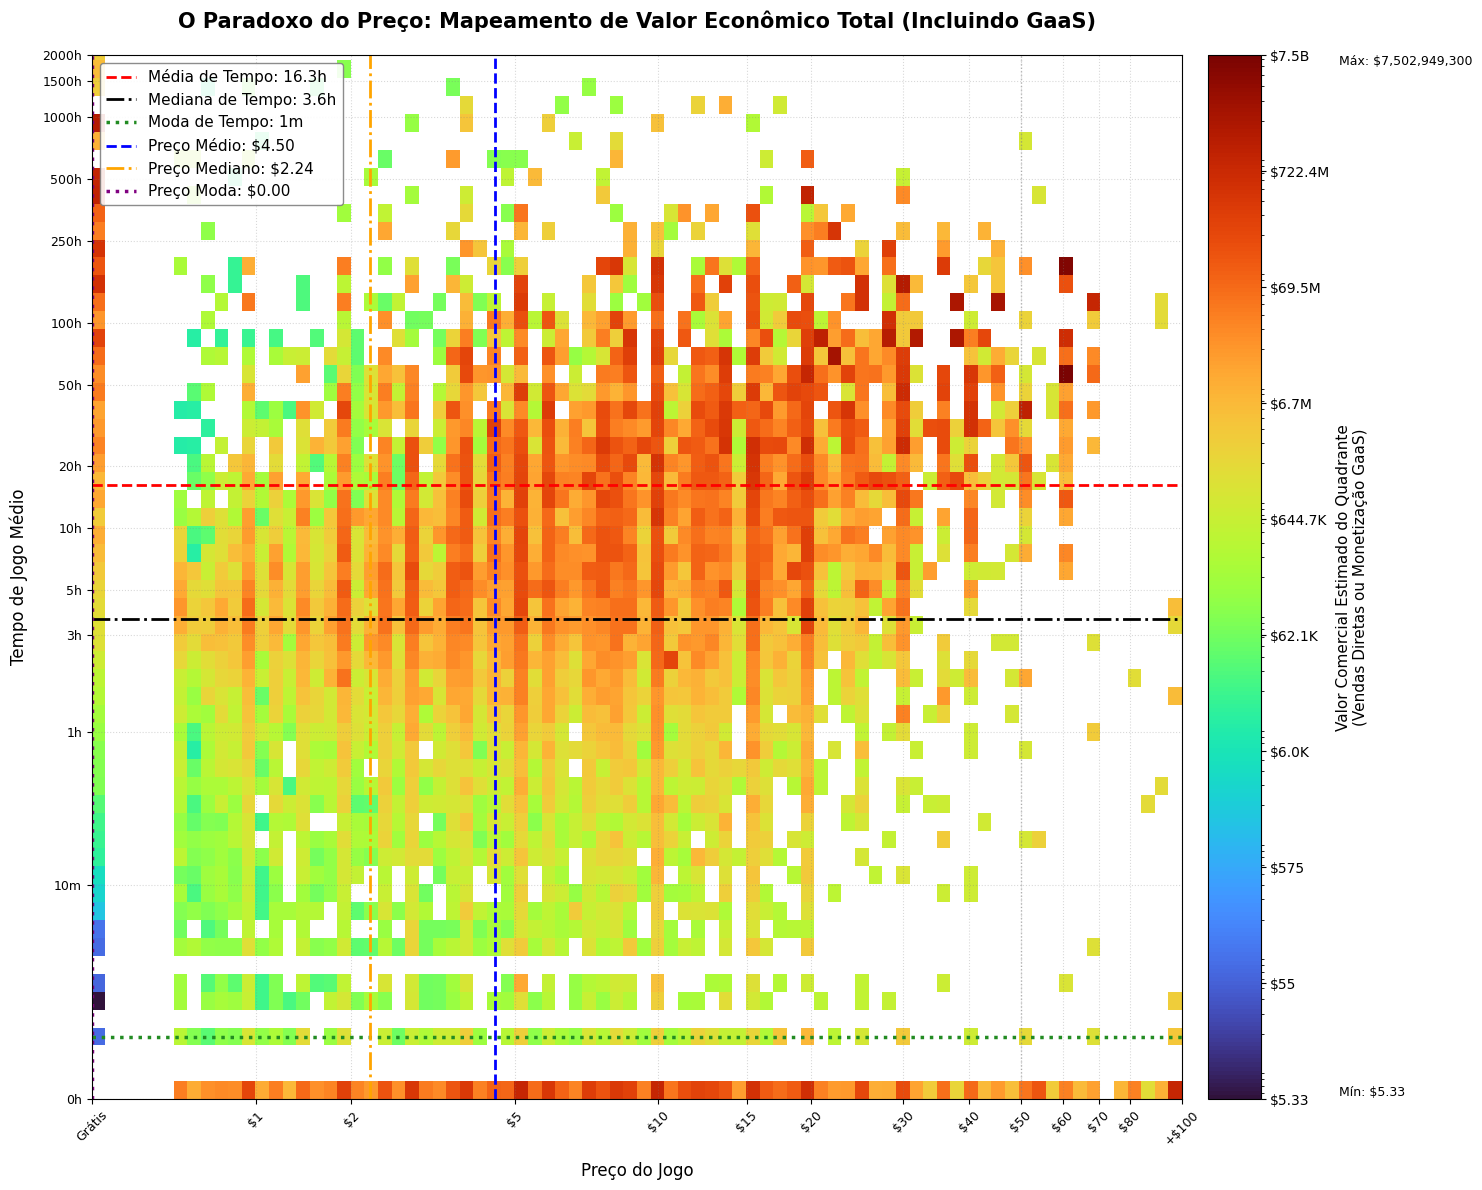

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LogNorm
from scipy import stats
import pandas as pd # Make sure pandas is imported

# --- Robustness Check and Preprocessing for 'Estimated_owners_numeric' and 'Price' ---
# This block ensures critical columns are correctly formatted,
# in case preceding cells were skipped or the kernel was reset.

# Ensure 'Estimated_owners_numeric' exists and is numeric
if 'Estimated_owners_numeric' not in df_games_csv_persistent.columns:
    print("Pre-processing: 'Estimated_owners_numeric' column not found. Attempting to create it.")

    # Check for original 'Estimated owners' column
    if 'Estimated owners' in df_games_csv_persistent.columns:
        df_games_csv_persistent = df_games_csv_persistent.rename(columns={'Estimated owners': 'Estimated_owners'})

    # If 'Estimated_owners' is still not present, or if 'Estimated owners' was the initial column
    # Ensure a consistent 'Estimated_owners' column for parsing
    if 'Estimated_owners' not in df_games_csv_persistent.columns and 'Estimated owners' in df_games_csv_persistent.columns:
        df_games_csv_persistent['Estimated_owners'] = df_games_csv_persistent['Estimated owners']
    elif 'Estimated_owners' not in df_games_csv_persistent.columns: # Fallback if neither original nor renamed column is found
        print("Warning: Neither 'Estimated owners' nor 'Estimated_owners' found. Cannot create 'Estimated_owners_numeric'. Setting to NaN.")
        df_games_csv_persistent['Estimated_owners_numeric'] = np.nan

    if 'Estimated_owners' in df_games_csv_persistent.columns:
        # Define parsing function to extract numeric value from 'X - Y' string format
        def parse_estimated_owners(owners_str):
            if isinstance(owners_str, str):
                parts = owners_str.replace(' ', '').split('-')
                if len(parts) == 2:
                    try:
                        return float(parts[1])
                    except ValueError:
                        return np.nan # Return NaN if conversion fails
            return np.nan # Return NaN for non-strings or unexpected formats

        df_games_csv_persistent['Estimated_owners_numeric'] = df_games_csv_persistent['Estimated_owners'].apply(parse_estimated_owners)
    else:
        # Fallback if somehow 'Estimated_owners' could not be established
        df_games_csv_persistent['Estimated_owners_numeric'] = np.nan


# Ensure 'Price' column is numeric (float64)
if 'Price' not in df_games_csv_persistent.columns or not pd.api.types.is_numeric_dtype(df_games_csv_persistent['Price']):
    print("Pre-processing: 'Price' column not found or not numeric. Attempting conversion.")
    if 'Price' in df_games_csv_persistent.columns:
        df_games_csv_persistent['Price'] = pd.to_numeric(df_games_csv_persistent['Price'].astype(str).replace(',', '.'), errors='coerce').fillna(0.0).astype(float)
    else:
        df_games_csv_persistent['Price'] = 0.0 # Default if column is entirely missing

# --- End of Robustness Check ---


# 1. Filtrar dados válidos (Garantindo que Estimated_owners_numeric existam e sejam >= 0)
df_price_playtime = df_games_csv_persistent[
    (df_games_csv_persistent['Price'] >= 0) &
    (df_games_csv_persistent['Average playtime forever'] >= 0) &
    (df_games_csv_persistent['Estimated_owners_numeric'] >= 0)
].copy()

# --- 🧠 MODIFICAÇÃO: MODELAGEM HÍBRIDA DE RECEITA (INCLUSÃO DE GAAS) ---
# 1. Calcular o tempo total que TODA a base de jogadores passou jogando (convertido para horas)
df_price_playtime['Total_Hours_Accumulated'] = (df_price_playtime['Average playtime forever'] / 60) * df_price_playtime['Estimated_owners_numeric']

# 2. Premissa de mercado: Jogos Free-to-Play geram uma média estimada de $0.03 por hora jogada via microtransações
F2P_monetization_rate = 0.008

# --- MODIFICAÇÃO: Ajuste na lógica de cálculo de Revenue para GaaS em jogos pagos ---
# Vendas Diretas (para jogos pagos)
direct_sales_revenue = df_price_playtime['Price'] * df_price_playtime['Estimated_owners_numeric']

# Monetização GaaS (aplicável apenas a jogos gratuitos, usando a premissa de F2P_monetization_rate)
gaas_monetization_revenue = df_price_playtime['Total_Hours_Accumulated'] * F2P_monetization_rate

# A Receita total usa a lógica condicional:
# Se o jogo é pago, a receita é apenas de vendas diretas.
# Se o jogo é gratuito, a receita é da monetização GaaS.
df_price_playtime['Revenue'] = np.where(
    df_price_playtime['Price'] > 0,
    direct_sales_revenue, # Para jogos pagos, considere apenas as vendas diretas
    gaas_monetization_revenue # Para jogos gratuitos, considere a monetização GaaS
)
# --- FIM DA MODIFICAÇÃO ---

# --- TRATAMENTO DOS PREÇOS (MOVED UP) ---
df_price_playtime['Price_Capped'] = np.where(df_price_playtime['Price'] > 100, 100, df_price_playtime['Price'])
df_price_playtime['Log_Price'] = np.log10(df_price_playtime['Price_Capped'] + 1)
df_price_playtime['Log_Playtime'] = np.log10(df_price_playtime['Average playtime forever'] + 1)

# --- CÁLCULO DAS MÉTRICAS ESTATÍSTICAS REAL (Em Minutos) ---
df_jogados = df_price_playtime[df_price_playtime['Average playtime forever'] > 0]

minutos_media = df_jogados['Average playtime forever'].mean()
minutos_mediana = df_jogados['Average playtime forever'].median()
minutos_moda = stats.mode(df_jogados['Average playtime forever'], keepdims=True).mode[0]

log_media = np.log10(minutos_media + 1)
log_mediana = np.log10(minutos_mediana + 1)
log_moda = np.log10(minutos_moda + 1)

# --- CÁLCULO DAS MÉTRICAS ESTATÍSTICAS DE PREÇO ---
# Filtrar jogos com preço maior ou igual a 0 para análise de preço
df_preco_valido = df_price_playtime[df_price_playtime['Price_Capped'] >= 0]

preco_media = df_preco_valido['Price_Capped'].mean()
preco_mediana = df_preco_valido['Price_Capped'].median()
# stats.mode returns an object, access mode[0] for the value
preco_moda = stats.mode(df_preco_valido['Price_Capped'], keepdims=True).mode[0]

log_preco_media = np.log10(preco_media + 1)
log_preco_mediana = np.log10(preco_mediana + 1)
log_preco_moda = np.log10(preco_moda + 1)



# 2. Preparar os dados do histograma 2D ponderado por RECEITA HÍBRIDA
x_data = df_price_playtime['Log_Price'].values
y_data = df_price_playtime['Log_Playtime'].values
weights_data = df_price_playtime['Revenue'].values

x_min, x_max = x_data.min(), x_data.max()
y_min, y_max = y_data.min(), y_data.max()

bins_x = np.linspace(x_min, x_max, 80 + 1)
bins_y = np.linspace(y_min, y_max, 75 + 1)

H_revenue, xedges, yedges = np.histogram2d(x_data, y_data, bins=[bins_x, bins_y], weights=weights_data)

H_revenue[H_revenue == 0] = np.nan

# Construct the label dynamically
from matplotlib.ticker import FuncFormatter

# Encontrar mínimo e máximo reais
valid_revenues = H_revenue[~np.isnan(H_revenue)]

if np.any(valid_revenues > 0):
    min_positive_revenue = np.min(valid_revenues[valid_revenues > 0])
else:
    min_positive_revenue = 0.01

max_revenue = np.nanmax(H_revenue)

# Evita problemas com log(0)
min_revenue_for_colorbar = max(0.01, min_positive_revenue)

# Escala logarítmica
log_colorbar_norm = LogNorm(
    vmin=min_revenue_for_colorbar,
    vmax=max_revenue
)

# 3. Configurar figura de alta resolução
fig, ax = plt.subplots(figsize=(15, 12), dpi=100)

# Plot do heatmap
mesh = ax.pcolormesh(
    xedges,
    yedges,
    H_revenue.T,
    cmap='turbo',
    norm=log_colorbar_norm,
    shading='auto'
)

# Colorbar
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)

# 10 marcações distribuídas logaritmicamente
ticks = np.geomspace(
    min_revenue_for_colorbar,
    max_revenue,
    10
)

cbar.set_ticks(ticks)

# Formatação monetária
def format_money(x, pos):
    if x >= 1_000_000_000:
        return f'${x/1_000_000_000:.1f}B'
    elif x >= 1_000_000:
        return f'${x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'${x/1_000:.1f}K'
    elif x >= 10: # If value is 10 or more, show as integer
        return f'${x:.0f}'
    elif x >= 1: # If value is between 1 and 10, show two decimals for better precision
        return f'${x:.2f}'
    else: # If value is less than 1, show two decimals
        return f'${x:.2f}'

cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(format_money)
)

# Título da barra
cbar.set_label(
    'Valor Comercial Estimado do Quadrante\n(Vendas Diretas ou Monetização GaaS)',
    fontsize=11
)

# Mostrar mínimo e máximo reais
cbar.ax.text(
    2.5,
    0,
    f'Mín: ${min_revenue_for_colorbar:,.2f}',
    transform=cbar.ax.transAxes,
    fontsize=9,
    va='bottom'
)

cbar.ax.text(
    2.5,
    1,
    f'Máx: ${max_revenue:,.0f}',
    transform=cbar.ax.transAxes,
    fontsize=9,
    va='top'
)

# --- LIMITE VERTICAL EXPANDIDO (Até 2.000 Horas) ---
ax.set_ylim(0, np.log10(120000 + 1))

# 5. Ajustar as marcações dos eixos
x_ticks = [0, 1, 2, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 100]
ax.set_xticks(np.log10(np.array(x_ticks) + 1))
x_labels = ['Grátis'] + [f"${x}" for x in x_ticks[1:-1]] + ['+$100']
ax.set_xticklabels(x_labels, rotation=45, fontsize=9)

y_ticks = [0, 10, 60, 180, 300, 600, 1200, 3000, 6000, 15000, 30000, 60000, 90000, 120000]
ax.set_yticks(np.log10(np.array(y_ticks) + 1))
ax.set_yticklabels(['0h', '10m', '1h', '3h', '5h', '10h', '20h', '50h', '100h', '250h', '500h', '1000h', '1500h', '2000h'], fontsize=9)

ax.grid(True, which='both', linestyle=':', alpha=0.3, color='gray')

# --- 🎯 LINHAS DAS MÉTRICAS ESTATÍSTICAS ---
def formatar_horas(minutos):
    horas = minutos / 60
    return f"{horas:.1f}h" if horas >= 1 else f"{int(minutos)}m"

ax.axhline(y=log_media, color='red', linestyle='--', linewidth=2,
           label=f'Média de Tempo: {formatar_horas(minutos_media)}')

ax.axhline(y=log_mediana, color='black', linestyle='-.', linewidth=2,
           label=f'Mediana de Tempo: {formatar_horas(minutos_mediana)}')

ax.axhline(y=log_moda, color='forestgreen', linestyle=':', linewidth=2.5,
           label=f'Moda de Tempo: {formatar_horas(minutos_moda)}')

# Linhas verticais para Média, Mediana e Moda de Preço
ax.axvline(x=log_preco_media, color='blue', linestyle='--', linewidth=2,
           label=f'Preço Médio: ${preco_media:.2f}')

ax.axvline(x=log_preco_mediana, color='orange', linestyle='-.', linewidth=2,
           label=f'Preço Mediano: ${preco_mediana:.2f}')

ax.axvline(x=log_preco_moda, color='purple', linestyle=':', linewidth=2.5,
           label=f'Preço Moda: ${preco_moda:.2f}')

ax.legend(loc='upper left', fontsize=11, facecolor='white', framealpha=0.9, edgecolor='gray')

# --- LINHA GUIA DE REFERÊNCIA DE PREÇO ($50) ---
ax.axvline(x=np.log10(50 + 1), color='gray', linestyle=':', alpha=0.5, linewidth=1)

ax.set_xlabel('Preço do Jogo', fontsize=12, labelpad=10)
ax.set_ylabel('Tempo de Jogo Médio', fontsize=12, labelpad=10)
plt.title('O Paradoxo do Preço: Mapeamento de Valor Econômico Total (Incluindo GaaS)', fontsize=15, pad=20, weight='bold')

plt.tight_layout()
plt.show()